In [1]:
### Import Packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import norm

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.linear_model import LinearRegression

from itertools import product
from matplotlib.backends.backend_pdf import PdfPages

import statsmodels.formula.api as smf

import statsmodels.api as sm

In [2]:
### Import Data
df = pd.read_csv('ED_Cleaned_Data.csv')

In [3]:
### Fix data type:

datetime_cols = [
    'arrival_time',
    'triage_time',
    'init_assess_time',
    'last_contact_time'
]

category_cols = [
    'client_id',
    'visit_id',
    'postal_code',
    'ED',
    'gender',
    'CTAS',
    'disposition',
    'arrival_mode',
    'ED_complaint',
    'chief_complaint',
    'period_of_day',
    'day_of_week',
    'season',
    'holiday',
    'admitted'
]

float_cols = [
    'age',
    'tot_lab_orders',
    'tot_lab_test_ordered',
    'avg_lab_order_time_min',
    'tot_diag_orders',
    'tot_diag_test_ordered',
    'avg_diag_order_time_min',
    'LOS_Hr',
    'wait_time_Hr',
    'service_time_min',
    'previous_visits'
]

df['service_time'] = pd.to_timedelta(
    df['service_time'],
    errors='coerce'
)

In [4]:
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

for col in category_cols:
    df[col] = df[col].astype('category')

for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911055 entries, 0 to 911054
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype          
---  ------                   --------------   -----          
 0   client_id                911055 non-null  category       
 1   visit_id                 911055 non-null  category       
 2   postal_code              899101 non-null  category       
 3   ED                       911055 non-null  category       
 4   gender                   911055 non-null  category       
 5   age                      911055 non-null  float64        
 6   arrival_time             911055 non-null  datetime64[ns] 
 7   triage_time              910898 non-null  datetime64[ns] 
 8   CTAS                     911055 non-null  category       
 9   tot_lab_orders           469110 non-null  float64        
 10  tot_lab_test_ordered     469110 non-null  float64        
 11  avg_lab_order_time_min   439750 non-null  float64        
 12  to

#### Service Time (workload groups) based on Lab and Diagnostic Orders

In [6]:
df_ST_lab_diag = df.copy()

In [7]:
### Omit extreme records from the data:

### Define upper threshold (remove top 1% of service time)
upper_threshold = df_ST_lab_diag['service_time_min'].quantile(0.99)

### Make a clean copy of the data: with non-negative service times and without extreme service times
df_ST_lab_diag = df_ST_lab_diag[
    (df_ST_lab_diag['service_time_min'] > 0) &
    (df_ST_lab_diag['service_time_min'] < upper_threshold)]

In [8]:
### Note: Age distribution for HSC (Pediatric) is significantly different from other EDs. Thus, we can remove the children's hospital data.
### To keep the children's hospital data comment this chunk.
### Moreover, if needed, we can focus on an individual ED by removing records for other EDs
### EDs available in the data: HSC-A, HSC-P, SBGH, GH

values_to_remove = ['HSC-P']
df_ST_lab_diag = df_ST_lab_diag[~df_ST_lab_diag['ED'].isin(values_to_remove)]

# Remove multiple categories at once
df_ST_lab_diag['ED'] = df_ST_lab_diag['ED'].cat.remove_categories(values_to_remove)

In [9]:
### Create Binary variables for lab/diagnostic orders

df_ST_lab_diag['has_lab'] = (df_ST_lab_diag['tot_lab_orders'] > 0).astype(int)
df_ST_lab_diag['has_diag'] = (df_ST_lab_diag['tot_diag_orders'] > 0).astype(int)

**Plan**:

We also have variables that directly capture resource use: Total LAB Orders, Total LAB Tests Ordered, Total Diagnostic Orders, and Total Diagnostic Tests Ordered. These capture patient workload/resource intensity.

We build a target using these variables (Note: lab tests and diagnostic tests are quite different in the ED. Lab tests may reflect one type of resource use, while diagnostic tests may reflect a different and often more resource-intensive pathway. So we should not simply treat them as equivalent).

We create separate lab-intensity and diagnostic-intensity measures, then define low, medium, and high workload groups based on these dimensions. For example, a patient could be considered high workload if they are high in either lab use or diagnostic use.


#### Train and Test Data

Note: We will be applying new rules to unseen data in the future. Thus, we create train and test data sets now itself.

In [10]:
# Train-test split
train_df, test_df = train_test_split(
    df_ST_lab_diag,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(train_df.shape)
print(test_df.shape)

(486128, 36)
(121532, 36)


#### Impact Analysis

Effect of additional lab/diagnostic orders on service time.

In [11]:
# Copy training data
df_impact = train_df.copy()

# Replace missing order counts with 0
df_impact['tot_lab_orders'] = df_impact['tot_lab_orders'].fillna(0)
df_impact['tot_diag_orders'] = df_impact['tot_diag_orders'].fillna(0)

# Log service time
df_impact['log_service_time'] = np.log(df_impact['service_time_min'] + 1)

In [12]:
impact_model = smf.ols(
    formula="""
    log_service_time ~
    tot_lab_orders +
    tot_diag_orders +
    age +
    previous_visits +
    C(CTAS) +
    C(ED) +
    C(arrival_mode) +
    C(period_of_day)
    """,
    data=df_impact
).fit()

In [13]:
print(impact_model.summary())

                            OLS Regression Results                            
Dep. Variable:       log_service_time   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                 1.462e+04
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        11:11:21   Log-Likelihood:            -7.8510e+05
No. Observations:              486128   AIC:                         1.570e+06
Df Residuals:                  486107   BIC:                         1.570e+06
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

**Summary of Regression Results:**

A linear regression model was fitted to investigate the relationship between service time and resource utilization variables, specifically total laboratory orders and total diagnostic orders. The response variable was log-transformed service time (`log(service_time_min + 1)`) to account for the strong right-skewness of service time.

Main findings:

- Both laboratory orders and diagnostic orders were strongly associated with increased service time (`p < 0.001`).

- The coefficient for `tot_lab_orders` was `0.1640`, suggesting that each additional laboratory order was associated with an approximate 17% increase in service time.

- The coefficient for `tot_diag_orders` was `0.3755`, suggesting that each additional diagnostic order was associated with an approximate 45% increase in service time.

- Diagnostic orders appeared to have a substantially larger impact on service time compared to laboratory orders.

Overall, these findings support the idea that laboratory and diagnostic utilization capture important aspects of patient workload and operational resource intensity in the emergency department. The stronger impact of diagnostic utilization also suggests that laboratory and diagnostic pathways should be treated separately when constructing workload groups.

#### Approach: Predict the actual number of lab and diagnostic orders directly

In [14]:
### Select patient-specific predictors
patient_features = [
    'gender',
    'age',
    'CTAS',
    'arrival_mode',
    'ED_complaint',
    'previous_visits'
]

In [15]:
### Prepare predictors
X_train = train_df[patient_features].copy()
X_test  = test_df[patient_features].copy()

X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test, drop_first=True)

X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [16]:
### Fit simple regression models
lab_reg_model = LinearRegression()
diag_reg_model = LinearRegression()

In [17]:
### Check for missing values
train_df[['tot_lab_orders', 'tot_diag_orders']].isna().sum()

tot_lab_orders     158688
tot_diag_orders    275101
dtype: int64

In [18]:
### Remove missing values
y_train_lab_orders = train_df['tot_lab_orders'].fillna(0)
y_train_diag_orders = train_df['tot_diag_orders'].fillna(0)

In [19]:
lab_reg_model.fit(X_train_enc, y_train_lab_orders)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
diag_reg_model.fit(X_train_enc, y_train_diag_orders)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
### Predict lab and diagnostic order counts
regression_results = test_df.copy()

# Fill missing true counts if needed
regression_results['tot_lab_orders'] = regression_results['tot_lab_orders'].fillna(0)
regression_results['tot_diag_orders'] = regression_results['tot_diag_orders'].fillna(0)

# Predicted counts
regression_results['pred_lab_orders'] = lab_reg_model.predict(X_test_enc)
regression_results['pred_diag_orders'] = diag_reg_model.predict(X_test_enc)

# Avoid negative predictions
regression_results['pred_lab_orders'] = regression_results['pred_lab_orders'].clip(lower=0)
regression_results['pred_diag_orders'] = regression_results['pred_diag_orders'].clip(lower=0)

In [22]:
### Define predicted intensity groups
def pred_lab_intensity(x):
    if x <= 2:
        return 'Low lab'
    elif x <= 5:
        return 'Medium lab'
    else:
        return 'High lab'


def pred_diag_intensity(x):
    if x <= 1:
        return 'Low diagnostic'
    elif x <= 2:
        return 'Medium diagnostic'
    else:
        return 'High diagnostic'

In [23]:
regression_results['pred_lab_intensity'] = regression_results['pred_lab_orders'].apply(pred_lab_intensity)
regression_results['pred_diag_intensity'] = regression_results['pred_diag_orders'].apply(pred_diag_intensity)

In [24]:
### Create final workload group
def workload_from_regression(row):
    
    if row['pred_lab_intensity'] == 'High lab' or row['pred_diag_intensity'] == 'High diagnostic':
        return 'High workload'
    
    elif row['pred_lab_intensity'] == 'Medium lab' or row['pred_diag_intensity'] == 'Medium diagnostic':
        return 'Medium workload'
    
    else:
        return 'Low workload'

In [25]:
regression_results['pred_workload_group'] = regression_results.apply(
    workload_from_regression,
    axis=1
)

In [26]:
### Group counts

In [27]:
regression_results['pred_workload_group'].value_counts()

pred_workload_group
Medium workload    71231
Low workload       27663
High workload      22638
Name: count, dtype: int64

In [28]:
regression_results['pred_workload_group'].value_counts(normalize=True)

pred_workload_group
Medium workload    0.586109
Low workload       0.227619
High workload      0.186272
Name: proportion, dtype: float64

In [29]:
### Service time summary
regression_results.groupby(
    'pred_workload_group',
    observed=True
)['service_time_min'].describe()

,count,mean,std,min,25%,50%,75%,max
pred_workload_group,,,,,,,,
High workload,22638.0,434.897429,400.197129,2.000000e-08,142.0,298.0,614.0,1917.0
Low workload,27663.0,101.689152,160.056273,2.000000e-08,20.0,52.0,118.0,1884.0
Medium workload,71231.0,259.511224,319.317534,2.000000e-08,54.0,146.0,321.0,1915.0


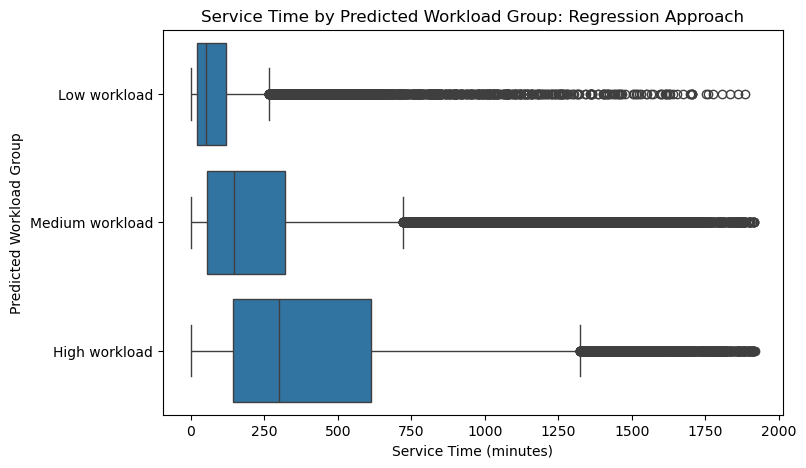

In [30]:
### Horizontal boxplot
plt.figure(figsize=(8,5))
sns.boxplot(
    data=regression_results,
    y='pred_workload_group',
    x='service_time_min',
    order=['Low workload', 'Medium workload', 'High workload']
)
plt.xlabel('Service Time (minutes)')
plt.ylabel('Predicted Workload Group')
plt.title('Service Time by Predicted Workload Group: Regression Approach')
plt.show()

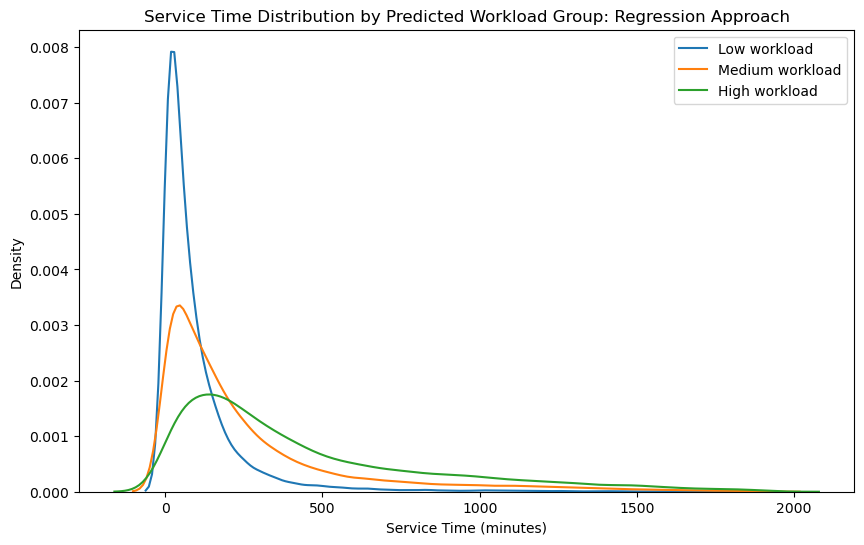

In [31]:
### Distribution plot
plt.figure(figsize=(10,6))

for group in ['Low workload', 'Medium workload', 'High workload']:
    subset = regression_results[
        regression_results['pred_workload_group'] == group
    ]['service_time_min']
    
    #subset = subset[subset < 1000]
    
    sns.kdeplot(
        subset,
        label=group,
        fill=False
    )
    
plt.xlabel('Service Time (minutes)')
plt.ylabel('Density')
plt.title('Service Time Distribution by Predicted Workload Group: Regression Approach')
plt.legend()
plt.show()

#### Data-Driven Cutoff Points

The goal of this section is to create a triage-time workload intensity score using predicted resource use. Since actual lab and diagnostic orders are not known when a new patient arrives, we first predict the expected number of lab orders and diagnostic orders using patient attributes available at triage.

Because lab and diagnostic orders may reflect different levels of resource intensity, they are not treated equally. Instead, the predicted counts are combined using weights obtained from the service-time impact analysis. The resulting workload score is used to classify patients into low, medium, and high expected workload groups.

Service time is not used to define the workload groups; it is used only afterward to evaluate whether the groups are operationally sensible.

In [32]:
# Extract weights from impact model
lab_weight = impact_model.params['tot_lab_orders']
diag_weight = impact_model.params['tot_diag_orders']

In [33]:
# Copy training data
train_workload = train_df.copy()

In [34]:
# Missing orders mean no orders
train_workload['tot_lab_orders'] = train_workload['tot_lab_orders'].fillna(0)
train_workload['tot_diag_orders'] = train_workload['tot_diag_orders'].fillna(0)

In [35]:
# Observed workload score in training data
train_workload['workload_score_obs'] = (
    lab_weight * train_workload['tot_lab_orders'] +
    diag_weight * train_workload['tot_diag_orders']
)

**Strategy 1: Tertiles (low: 33%, medium: 33%, high: 33%)**

In [36]:
cutoff_low = train_workload['workload_score_obs'].quantile(1/3)
cutoff_high = train_workload['workload_score_obs'].quantile(2/3)

print("Low/Medium cutoff:", cutoff_low)
print("Medium/High cutoff:", cutoff_high)

def assign_workload_group(score):
    if score < cutoff_low:
        return 'Low'
    elif score < cutoff_high:
        return 'Medium'
    else:
        return 'High'

# Observed workload group in training data
train_workload['workload_group_obs'] = train_workload['workload_score_obs'].apply(assign_workload_group)

train_workload['workload_group_obs'].value_counts(normalize=True)

Low/Medium cutoff: 0.3754615801564719
Medium/High cutoff: 0.9837832450821041


workload_group_obs
High      0.352249
Medium    0.350490
Low       0.297261
Name: proportion, dtype: float64

In [37]:
### Apply Training Cutoffs to Test Predictions

In [38]:
regression_results['workload_score_pred'] = (
    lab_weight * regression_results['pred_lab_orders'] +
    diag_weight * regression_results['pred_diag_orders']
)

regression_results['workload_group_pred'] = regression_results['workload_score_pred'].apply(assign_workload_group)

regression_results['workload_group_pred'].value_counts(normalize=True)

workload_group_pred
Medium    0.510927
High      0.332596
Low       0.156477
Name: proportion, dtype: float64

In [39]:
### Validate Predicted Workload Groups Using Test Service Time

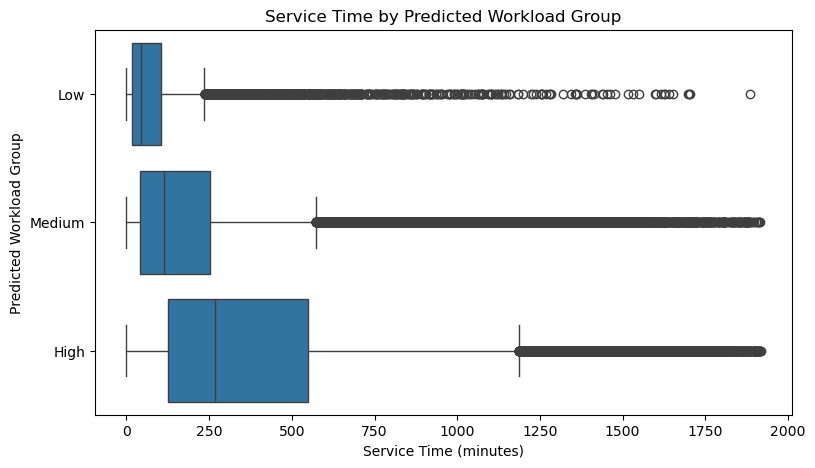

In [40]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=regression_results,
    y='workload_group_pred',
    x='service_time_min',
    order=['Low', 'Medium', 'High']
)
plt.title('Service Time by Predicted Workload Group')
plt.xlabel('Service Time (minutes)')
plt.ylabel('Predicted Workload Group')
#plt.savefig("1.png", dpi=300, bbox_inches="tight")
plt.show()

**Strategy 2: Quartiles (low: 25%, medium: 50%, high: 25%)**

In [41]:
cutoff_low = train_workload['workload_score_obs'].quantile(0.25)
cutoff_high = train_workload['workload_score_obs'].quantile(0.75)

print("Low/Medium cutoff:", cutoff_low)
print("Medium/High cutoff:", cutoff_high)

def assign_workload_group(score):
    if score < cutoff_low:
        return 'Low'
    elif score < cutoff_high:
        return 'Medium'
    else:
        return 'High'

# Observed workload group in training data
train_workload['workload_group_obs'] = train_workload['workload_score_obs'].apply(assign_workload_group)

train_workload['workload_group_obs'].value_counts(normalize=True)

Low/Medium cutoff: 0.0
Medium/High cutoff: 1.1477471192624549


workload_group_obs
Medium    0.734769
High      0.265231
Name: proportion, dtype: float64

In [42]:
### Apply Training Cutoffs to Test Predictions

In [43]:
regression_results['workload_score_pred'] = (
    lab_weight * regression_results['pred_lab_orders'] +
    diag_weight * regression_results['pred_diag_orders']
)

regression_results['workload_group_pred'] = regression_results['workload_score_pred'].apply(assign_workload_group)

regression_results['workload_group_pred'].value_counts(normalize=True)

workload_group_pred
Medium    0.805566
High      0.194434
Name: proportion, dtype: float64

In [44]:
### Validate Predicted Workload Groups Using Test Service Time

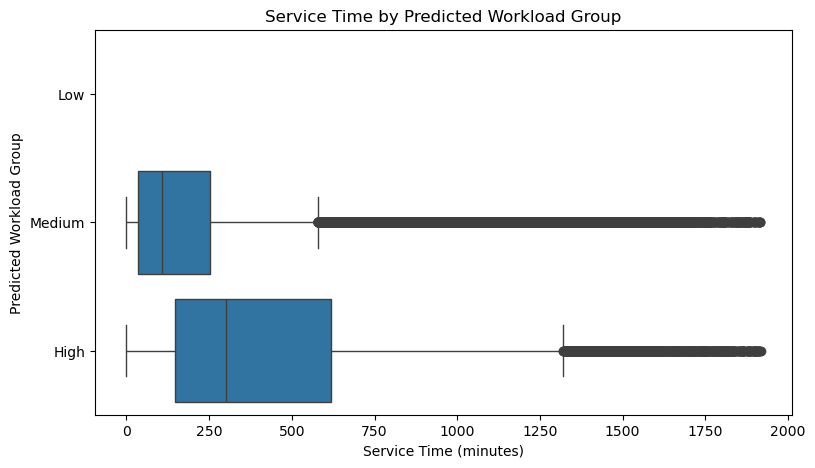

In [45]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=regression_results,
    y='workload_group_pred',
    x='service_time_min',
    order=['Low', 'Medium', 'High']
)
plt.title('Service Time by Predicted Workload Group')
plt.xlabel('Service Time (minutes)')
plt.ylabel('Predicted Workload Group')
#plt.savefig("2.png", dpi=300, bbox_inches="tight")
plt.show()

**Strategy 3: Extreme-Focused (low: 20%, medium: 60%, high: 20%)**

In [46]:
cutoff_low = train_workload['workload_score_obs'].quantile(0.20)
cutoff_high = train_workload['workload_score_obs'].quantile(0.80)

print("Low/Medium cutoff:", cutoff_low)
print("Medium/High cutoff:", cutoff_high)

def assign_workload_group(score):
    if score < cutoff_low:
        return 'Low'
    elif score < cutoff_high:
        return 'Medium'
    else:
        return 'High'

# Observed workload group in training data
train_workload['workload_group_obs'] = train_workload['workload_score_obs'].apply(assign_workload_group)

train_workload['workload_group_obs'].value_counts(normalize=True)

Low/Medium cutoff: 0.0
Medium/High cutoff: 1.3117109934428055


workload_group_obs
Medium    0.797424
High      0.202576
Name: proportion, dtype: float64

In [47]:
### Apply Training Cutoffs to Test Predictions

In [48]:
regression_results['workload_score_pred'] = (
    lab_weight * regression_results['pred_lab_orders'] +
    diag_weight * regression_results['pred_diag_orders']
)

regression_results['workload_group_pred'] = regression_results['workload_score_pred'].apply(assign_workload_group)

regression_results['workload_group_pred'].value_counts(normalize=True)

workload_group_pred
Medium    0.894744
High      0.105256
Name: proportion, dtype: float64

In [49]:
### Validate Predicted Workload Groups Using Test Service Time

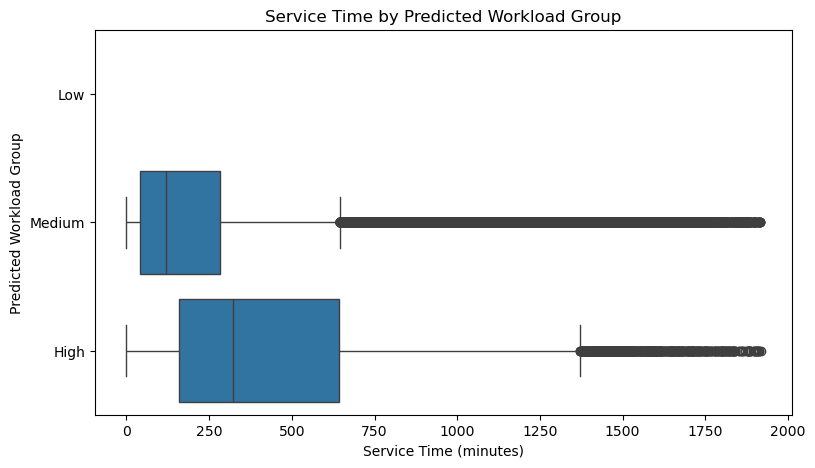

In [50]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=regression_results,
    y='workload_group_pred',
    x='service_time_min',
    order=['Low', 'Medium', 'High']
)
plt.title('Service Time by Predicted Workload Group')
plt.xlabel('Service Time (minutes)')
plt.ylabel('Predicted Workload Group')
#plt.savefig("3.png", dpi=300, bbox_inches="tight")
plt.show()

**Strategy 4: Operational (low: 50%, medium: 35%, high: 15%)**

In [51]:
cutoff_low = train_workload['workload_score_obs'].quantile(0.50)
cutoff_high = train_workload['workload_score_obs'].quantile(0.85)

print("Low/Medium cutoff:", cutoff_low)
print("Medium/High cutoff:", cutoff_high)

def assign_workload_group(score):
    if score < cutoff_low:
        return 'Low'
    elif score < cutoff_high:
        return 'Medium'
    else:
        return 'High'

# Observed workload group in training data
train_workload['workload_group_obs'] = train_workload['workload_score_obs'].apply(assign_workload_group)

train_workload['workload_group_obs'].value_counts(normalize=True)

Low/Medium cutoff: 0.6558554967214028
Medium/High cutoff: 1.4756748676231561


workload_group_obs
Low       0.440800
Medium    0.403301
High      0.155899
Name: proportion, dtype: float64

In [52]:
### Apply Training Cutoffs to Test Predictions

In [53]:
regression_results['workload_score_pred'] = (
    lab_weight * regression_results['pred_lab_orders'] +
    diag_weight * regression_results['pred_diag_orders']
)

regression_results['workload_group_pred'] = regression_results['workload_score_pred'].apply(assign_workload_group)

regression_results['workload_group_pred'].value_counts(normalize=True)

workload_group_pred
Medium    0.568912
Low       0.379456
High      0.051632
Name: proportion, dtype: float64

In [54]:
### Validate Predicted Workload Groups Using Test Service Time

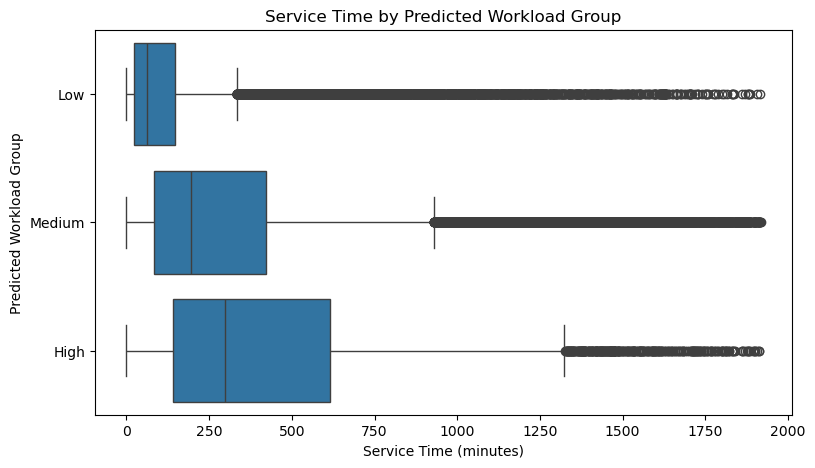

In [55]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=regression_results,
    y='workload_group_pred',
    x='service_time_min',
    order=['Low', 'Medium', 'High']
)
plt.title('Service Time by Predicted Workload Group')
plt.xlabel('Service Time (minutes)')
plt.ylabel('Predicted Workload Group')
#plt.savefig("4.png", dpi=300, bbox_inches="tight")
plt.show()

Among the evaluated workload grouping strategies, the tertile-based strategy was selected for subsequent analysis. Although some alternative strategies produced stronger separation between workload groups in the training data, they resulted in unstable predictions and the disappearance of certain workload classes when applied to the test data. In contrast, the tertile-based strategy preserved all workload groups after prediction while still showing a meaningful increase in service time from low- to high-workload patients. Therefore, this strategy provided the best balance between predictive stability and operational interpretability.